# 02 — Attach political party

Read the v1 parquet from notebook 01, match `page_name` and `bylines` against the 2022 AEC candidate list, add a `political_party` column (`PartyAb` or null), and write a new v2 parquet partitioned by party.

spin up spark.

In [1]:
from pyspark.sql import SparkSession
import pandas as pd
import re

# Override the parquet output committer — the cluster default points at an EMR
# class whose JAR isn't on the classpath, which breaks .write.parquet otherwise.
spark = SparkSession.builder \
    .appName('FB_API_party_match') \
    .config('spark.sql.parquet.output.committer.class',
            'org.apache.parquet.hadoop.ParquetOutputCommitter') \
    .config('mapreduce.fileoutputcommitter.algorithm.version', '2') \
    .getOrCreate()

print('Master:', spark.sparkContext.master)
print('Spark version:', spark.version)

Master: yarn
Spark version: 3.5.0


26/05/16 07:41:02 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


paths.

In [2]:
IN_PATH        = '/user/s3348393/main/preprocessing/v1/parquet'
OUT_PATH       = '/user/s3348393/main/preprocessing/v2/parquet'
HOUSE_CSV      = '../data/2022_election_candidates.csv'
SENATE_CSV     = '../data/2022_senate_candidates.csv'
PARTIES_CSV    = '../data/aec_parties.csv'

load the v1 parquet and peek at the schema.

In [ ]:
from pyspark.sql.functions import col

df = spark.read.parquet(IN_PATH)
print(f'Total rows: {df.count():>10,}')
print(f'Unique ads: {df.filter(col("ad_seq_no") == 1).count():>10,}')
df.printSchema()

load the 2022 candidates — house + senate. the house csv (DivisionNm, PartyAb, PartyNm, Surname, GivenNm) and senate csv (state, PartyAB, PartyNm, Surname, GivenNm — PartyAB filled in by 01_5_senate_party_codes.ipynb) have the columns we need. rename the senate PartyAB to PartyAb and concat into one df so the candidate loop in cell 6 can treat them as a single source.

In [4]:
house  = pd.read_csv(HOUSE_CSV,  header=0)
senate = pd.read_csv(SENATE_CSV, header=0).rename(columns={'PartyAB': 'PartyAb'})

candidates = pd.concat(
    [house[['PartyAb', 'PartyNm', 'Surname', 'GivenNm']],
     senate[['PartyAb', 'PartyNm', 'Surname', 'GivenNm']]],
    ignore_index=True,
)

print('House candidates: ', len(house))
print('Senate candidates:', len(senate))
print('Combined:         ', len(candidates))
candidates.head()

House candidates:  1203
Senate candidates: 421
Combined:          1624


,PartyAb,PartyNm,Surname,GivenNm
0,ALP,Australian Labor Party,ABBOTT,Martyn
1,GVIC,The Greens,ABBOUD,Natalie
2,GRN,The Greens (WA),ABDUL RAZAK,Adam
3,LDP,Liberal Democrats,ABELMAN,Michael
4,ALP,Australian Labor Party,ABHIMANYU KUMAR,NaN


tokenise page_name and bylines separately. spark mllib's RegexTokenizer (splits on \W+, lowercases) then StopWordsRemover with the english defaults plus a few political honorifics. we keep the fields separate so a given name in page_name doesnt cross with a surname in bylines and spuriously match a candidate.

coalesce(col, lit('')) because RegexTokenizer blows up on nulls.

In [5]:
from pyspark.sql.functions import coalesce, col, lit
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover

df = df.withColumn('page_name_safe', coalesce(col('page_name'), lit(''))) \
       .withColumn('bylines_safe',   coalesce(col('bylines'),   lit('')))

honorifics = ['mp', 'hon', 'dr', 'mr', 'mrs', 'ms', 'sen', 'senator', 'rt', 'authorised', 'by', 'for']
stopwords = StopWordsRemover.loadDefaultStopWords('english') + honorifics

for src, tok_col, term_col in [
    ('page_name_safe', 'page_name_tokens', 'page_name_terms'),
    ('bylines_safe',   'bylines_tokens',   'bylines_terms'),
]:
    df = RegexTokenizer(inputCol=src, outputCol=tok_col, pattern=r'\W+', toLowercase=True).transform(df)
    df = StopWordsRemover(inputCol=tok_col, outputCol=term_col, stopWords=stopwords).transform(df)

df.select('page_name', 'page_name_terms', 'bylines', 'bylines_terms').show(5, truncate=80)

+-----------------------------+----------------------------+-------+-------------+
|                    page_name|             page_name_terms|bylines|bylines_terms|
+-----------------------------+----------------------------+-------+-------------+
|                   The Clocks|                    [clocks]|   NULL|           []|
|                   The Clocks|                    [clocks]|   NULL|           []|
|                   The Clocks|                    [clocks]|   NULL|           []|
|Your family tee M 101 - 200N1|[family, tee, m, 101, 200n1]|   NULL|           []|
|Your family tee M 101 - 200N1|[family, tee, m, 101, 200n1]|   NULL|           []|
+-----------------------------+----------------------------+-------+-------------+
only showing top 5 rows



build the candidate match index. for each candidate the required tokens are the first given-name token plus all surname tokens — e.g. Adam ABDUL RAZAK becomes {adam, abdul, razak}. token-set subset matching is order-insensitive so "Adam Abdul Razak" and "Abdul Razak, Adam" both match.

we'd rather not scan all ~1,500 candidates per ad — we'll just check candidates whose key token appears in the ad's token list.

In [6]:
def split_tokens(s):
    if not isinstance(s, str):
        return []
    return [t for t in re.split(r'\W+', s.lower()) if t]

candidate_list = []
for _, row in candidates.iterrows():
    surname_toks = split_tokens(row['Surname'])
    if not surname_toks:
        continue
    given_toks = split_tokens(row['GivenNm'])
    required = frozenset(surname_toks + given_toks[:1])
    party = row['PartyAb']
    if not isinstance(party, str):
        continue
    candidate_list.append((required, party))

print('Candidates indexed:', len(candidate_list))

Candidates indexed: 1623


classify each ad. two new columns.

political_party is the AEC party code (ALP, LP, etc) when the ad's from a registered-party candidate or party office. null otherwise.

match_type tells us how we got there. candidate means a 2022 candidate's name (house or senate) shows up in page_name or bylines. party_org means a party-name signature from aec_parties.csv matches the byline (e.g. byline = "Australian Labor Party"). government means the byline is a govt dept or agency (e.g. "Department of Social Services", "Australian Electoral Commission", "Australian Cyber Security Centre"). commercial means a known commercial advertiser with election-aligned spend timing but non-political content (e.g. "Shell") — gets filtered out downstream. null means none of the above.

priority is candidate then party_org then government then commercial. if more than one candidate matches and they disagree on party, we drop the row and let it fall through to the byline checks. filter on match_type IS NULL AND bylines IS NOT NULL to surface the leftover political-looking bylines (NGOs, unions, advocacy orgs, third-party advertisers) for triage.

In [7]:
from pyspark.sql.functions import pandas_udf
from pyspark.sql.types import StringType, StructType, StructField

# Party-name byline signatures: rows where byline_tokens is non-empty in aec_parties.csv,
# preserving CSV order so specific signatures (e.g. {liberal, national}) match before
# single-token signatures ({liberal}).
aec_parties = pd.read_csv(PARTIES_CSV, header=0)

party_byline_signatures = []
for _, row in aec_parties.iterrows():
    bt = row['byline_tokens']
    if not isinstance(bt, str) or not bt.strip():
        continue
    sig = frozenset(t.strip() for t in bt.split('+') if t.strip())
    party_byline_signatures.append((sig, row['party_ab']))

# Government byline signatures. Narrow enough to avoid private-sector collisions.
# {commonwealth} was dropped — too high a false-positive risk against Commonwealth Bank.
GOV_BYLINE_SIGNATURES = [
    frozenset({'department'}),                          # "Department of X" — covers most departments
    frozenset({'australian', 'government'}),            # "Australian Government" prefix
    frozenset({'australian', 'electoral', 'commission'}),
    frozenset({'australian', 'cyber', 'security'}),     # Australian Cyber Security Centre
]

# Commercial byline signatures. Known commercial advertisers whose spend timing
# looks election-aligned but whose content is not political. Tagged as
# 'commercial' so they're dropped in the v3 filter alongside government rows.
COMMERCIAL_BYLINE_SIGNATURES = [
    frozenset({'shell'}),  # Shell (energy company)
]

print('Party-org byline signatures: ', len(party_byline_signatures))
print('Government byline signatures:', len(GOV_BYLINE_SIGNATURES))
print('Commercial byline signatures:', len(COMMERCIAL_BYLINE_SIGNATURES))

# Combined classifier — pandas UDF, returns a DataFrame with (political_party, match_type)
# per input row. Pandas UDFs use Arrow to batch data between JVM and Python workers,
# eliminating per-row serialisation overhead vs a plain @udf — typically 3-10× faster.
result_schema = StructType([
    StructField('political_party', StringType(), True),
    StructField('match_type',      StringType(), True),
])

def _classify_one(page_tokens, bylines_tokens):
    # pandas_udf hands array columns to Python as numpy arrays, not lists.
    # `array or []` would call bool(array) — ambiguous for multi-element arrays.
    # Use explicit None checks to convert to set safely.
    page_set    = set(page_tokens)    if page_tokens    is not None else set()
    bylines_set = set(bylines_tokens) if bylines_tokens is not None else set()

    # 1. Candidate name match (House + Senate)
    parties = set()
    for required, party in candidate_list:
        if required.issubset(page_set) or required.issubset(bylines_set):
            parties.add(party)
    if len(parties) == 1:
        return (next(iter(parties)), 'candidate')
    # Ambiguous (>1 party) or no match — fall through.

    # 2. Party-name byline signature
    for sig, party in party_byline_signatures:
        if sig.issubset(bylines_set):
            return (party, 'party_org')

    # 3. Government byline signature
    for sig in GOV_BYLINE_SIGNATURES:
        if sig.issubset(bylines_set):
            return (None, 'government')

    # 4. Commercial byline signature
    for sig in COMMERCIAL_BYLINE_SIGNATURES:
        if sig.issubset(bylines_set):
            return (None, 'commercial')

    return (None, None)


@pandas_udf(result_schema)
def classify_ad(page_terms: pd.Series, bylines_terms: pd.Series) -> pd.DataFrame:
    results = [_classify_one(p, b) for p, b in zip(page_terms, bylines_terms)]
    return pd.DataFrame(results, columns=['political_party', 'match_type'])


df = df.withColumn('_class', classify_ad('page_name_terms', 'bylines_terms'))
df = df.withColumn('political_party', col('_class.political_party')) \
       .withColumn('match_type',      col('_class.match_type')) \
       .drop('_class')

Party-org byline signatures:  14
Government byline signatures: 4
Commercial byline signatures: 1


sanity check the counts.

In [8]:
from pyspark.sql.functions import sum as spark_sum, when

(df.groupBy('political_party')
   .agg(
       spark_sum(lit(1)).alias('total_rows'),
       spark_sum(when(col('ad_seq_no') == 1, 1).otherwise(0)).alias('unique_ads'),
   )
   .orderBy(col('unique_ads').desc())
   .show(50, truncate=False))

+---------------+----------+----------+
|political_party|total_rows|unique_ads|
+---------------+----------+----------+
|NULL           |36895224  |11748192  |
|ALP            |1039655   |45933     |
|LP             |829539    |24364     |
|GRN            |266908    |10395     |
|LNP            |100291    |6056      |
|AJP            |149638    |4697      |
|IND            |96852     |4402      |
|NP             |31765     |1967      |
|ON             |56026     |1470      |
|LDP            |20892     |1166      |
|UAPP           |18950     |1140      |
|GVIC           |15685     |521       |
|TNL            |5406      |494       |
|CLP            |9532      |399       |
|KAP            |4443      |392       |
|JLN            |15010     |345       |
|AUVA           |15920     |330       |
|CYA            |2736      |142       |
|REAS           |2665      |109       |
|VNS            |1229      |84        |
|WAP            |276       |55        |
|XEN            |1150      |47        |


In [9]:
# breakdown by match_type — total rows alongside unique ads
from pyspark.sql.functions import sum as spark_sum, when

(df.groupBy('match_type')
   .agg(
       spark_sum(lit(1)).alias('total_rows'),
       spark_sum(when(col('ad_seq_no') == 1, 1).otherwise(0)).alias('unique_ads'),
   )
   .orderBy(col('unique_ads').desc())
   .show(truncate=False))

+----------+----------+----------+
|match_type|total_rows|unique_ads|
+----------+----------+----------+
|NULL      |36675573  |11745227  |
|party_org |1465703   |53629     |
|candidate |1223212   |51083     |
|government|219597    |2962      |
|commercial|54        |3         |
+----------+----------+----------+



same diagnostics, but plotted for the report. each chart aggregates in spark on the cached df, then materialises a small result to pandas for matplotlib — no full corpus collection.

four views. classification breakdown — donut showing the candidate / party_org / government / unclassified split. top parties — horizontal bar of classified ad counts (nulls excluded). classification source per party — for the top 8 parties, candidate-name match vs party-org byline fallback. weekly spend by classification — the election spike in candidate + party_org against the steady government / unclassified baselines is the temporal story we pick up in nb 05.

In [ ]:
import matplotlib.pyplot as plt

# Consistent palette for the five classification categories — reused across
# every chart in this section so they read as one figure family.
MT_COLORS = {
    'candidate':    '#1f77b4',
    'party_org':    '#ff7f0e',
    'government':   '#2ca02c',
    'commercial':   '#d62728',
    'unclassified': '#7f7f7f',
}

# Headline classification breakdown — what fraction of ads landed in each bucket.
mt = df.groupBy('match_type').count().toPandas()
mt['match_type'] = mt['match_type'].fillna('unclassified')
mt = mt.set_index('match_type').reindex(MT_COLORS.keys()).dropna()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    mt['count'],
    labels=[f'{k}\n{int(v):,}' for k, v in mt['count'].items()],
    colors=[MT_COLORS[k] for k in mt.index],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4),
)
ax.set_title('Ad classification breakdown')
plt.tight_layout()
plt.show()

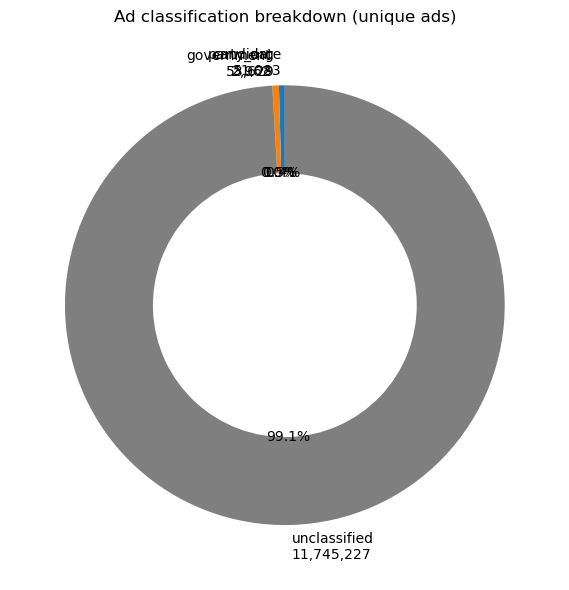

In [11]:
# Same breakdown but on *unique* ads — filter to one row per ad (ad_seq_no == 1)
# so the chart reflects ad counts rather than the multi-row v2 representation.
mt_unique = (df.filter(col('ad_seq_no') == 1)
               .groupBy('match_type').count().toPandas())
mt_unique['match_type'] = mt_unique['match_type'].fillna('unclassified')
mt_unique = mt_unique.set_index('match_type').reindex(MT_COLORS.keys()).dropna()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    mt_unique['count'],
    labels=[f'{k}\n{int(v):,}' for k, v in mt_unique['count'].items()],
    colors=[MT_COLORS[k] for k in mt_unique.index],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4),
)
ax.set_title('Ad classification breakdown (unique ads)')
plt.tight_layout()
plt.show()

In [12]:
# Weekly spend by match_type — temporal preview of the classifier's separation power.
# Aggregate in Spark on the cached df, then materialise to pandas for matplotlib.
from pyspark.sql.functions import date_trunc, sum as spark_sum
import pandas as pd

weekly = (df.filter(col('ad_seq_no') == 1)
            .filter(col('spend_mid').isNotNull())
            .withColumn('week', date_trunc('week', 'ad_creation_date'))
            .groupBy('week', 'match_type')
            .agg(spark_sum('spend_mid').alias('spend'))
            .orderBy('week')
            .toPandas())

weekly['match_type'] = weekly['match_type'].fillna('unclassified')
pivot = weekly.pivot(index='week', columns='match_type', values='spend').fillna(0)
order = [c for c in ['candidate', 'party_org', 'government', 'unclassified'] if c in pivot.columns]
pivot = pivot[order]

fig, ax = plt.subplots(figsize=(13, 5))
pivot.plot.area(ax=ax, color=[MT_COLORS[c] for c in pivot.columns], alpha=0.75)
ax.axvline(pd.Timestamp('2022-05-21'), linestyle='--', color='red', linewidth=1.5)
ax.text(pd.Timestamp('2022-05-22'), ax.get_ylim()[1] * 0.95, ' Election day',
        color='red', va='top')
ax.set_title('Weekly spend (latest snapshot) by classification — ad-creation week')
ax.set_ylabel('Spend ($)')
ax.set_xlabel('Week')
ax.legend(title='match_type', loc='upper right')
plt.tight_layout()
plt.show()

26/05/16 07:45:27 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `spend_mid` cannot be resolved. Did you mean one of the following? [`spend`, `page_id`, `id`, `page_name`, `bylines`].;
'Filter isnotnull('spend_mid)
+- Filter (ad_seq_no#21 = 1)
   +- Project [id#0, page_id#1, page_name#2, snapshot_date#3, ad_creation_date#4, ad_delivery_start_date#5, ad_delivery_stop_date#6, creative_bodies#7, creative_link_captions#8, creative_link_descs#9, creative_link_titles#10, impressions#11, spend#12, estimated_audience_size#13, currency#14, languages#15, publisher_platforms#16, demographic_distribution#17, delivery_by_region#18, ad_snapshot_url#19, bylines#20, ad_seq_no#21, page_name_safe#99, bylines_safe#123, ... 6 more fields]
      +- Project [id#0, page_id#1, page_name#2, snapshot_date#3, ad_creation_date#4, ad_delivery_start_date#5, ad_delivery_stop_date#6, creative_bodies#7, creative_link_captions#8, creative_link_descs#9, creative_link_titles#10, impressions

In [ ]:
# Residual third-party political-looking bylines:
# match_type IS NULL excludes candidate, party_org, AND government matches —
# what's left is non-party non-government political-adjacent advertising
# (NGOs, unions, advocacy orgs, industry bodies, individual political advertisers).
from pyspark.sql.functions import sum as spark_sum, when

(df.filter(col('match_type').isNull() & col('bylines').isNotNull())
   .groupBy('bylines')
   .agg(
       spark_sum(lit(1)).alias('total_rows'),
       spark_sum(when(col('ad_seq_no') == 1, 1).otherwise(0)).alias('unique_ads'),
   )
   .orderBy(col('unique_ads').desc())
   .show(30, truncate=80))

+--------------------------------------+----------+----------+
|                               bylines|total_rows|unique_ads|
+--------------------------------------+----------+----------+
|          Greenpeace Australia Pacific|    546415|      9661|
|                                Access|     91188|      6787|
|                         Private Media|     51370|      3021|
|       Amnesty International Australia|     71893|      2262|
|    Australian Conservation Foundation|     82823|      2229|
|                       Oxfam Australia|    121311|      2139|
|               Solutions for Australia|     32078|      1819|
|                The Wilderness Society|     74450|      1518|
|     Australian Automobile Association|     58804|      1397|
|                           Climate 200|     28285|      1351|
|                   Australia for UNHCR|    168107|      1331|
|                        Thrive By Five|     72557|      1100|
|           Save the Children Australia|     46915|    

write v2 parquet, partitioned by party. drop the intermediate token/term columns before writing — they're big arrays and easy to rebuild. rows with political_party = null land in political_party=__HIVE_DEFAULT_PARTITION__/ (expected — that's the bulk of the corpus).

In [ ]:
intermediate = ['page_name_safe', 'bylines_safe',
                'page_name_tokens', 'bylines_tokens',
                'page_name_terms', 'bylines_terms']

out = df.drop(*intermediate)

# Defensive: re-override the parquet committer at write time. SparkSession.builder
# in cell 2 is a no-op if a session is already running, so an old kernel-state may
# still carry the cluster's broken EMR default.
spark.conf.set('spark.sql.parquet.output.committer.class',
               'org.apache.parquet.hadoop.ParquetOutputCommitter')

out.write \
   .partitionBy('political_party') \
   .option('mapreduce.fileoutputcommitter.algorithm.version', '2') \
   .parquet(OUT_PATH, mode='overwrite')
print('Wrote:', OUT_PATH)

26/05/16 06:47:29 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Wrote: /user/s3348393/main/preprocessing/v2/parquet
